# Model Comparison

All three models - **Logistic Regression**, **SVM (RBF)**, and **Neural Network** - are compared side-by-side on accuracy, precision, recall, and F1-score for the malignant class on the same 114-sample stratified test set.

In a medical context, **recall for the malignant class is the most important metric** - a false negative (missed cancer) has more serious consequences than a false positive.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Load Ground Truth Labels

The true test labels are loaded from `data/processedData/`. This is the only data needed here — predictions come from the individual model notebooks.

In [26]:
Y_test = pd.read_csv("../data/processedData/Y_test.csv", index_col=0).values.ravel()

print(f"Test samples: {Y_test.shape[0]}")

Test samples: 114


## Load Predictions

Each model notebook saves its test-set predictions to `data/models/` when run. Load them here so no retraining is needed.

> **Run order:** execute `logistic_regression.ipynb`, `svm_classifier.ipynb`, and `breast_cancer_neural_network.ipynb` first to generate the prediction files.

In [27]:
import numpy as np

lr_pred  = np.loadtxt("../data/models/lr_predictions.csv",  delimiter=",", dtype=int)
svm_pred = np.loadtxt("../data/models/svm_predictions.csv", delimiter=",", dtype=int)
nn_preds = np.loadtxt("../data/models/nn_predictions.csv",  delimiter=",", dtype=int)

print(f"Loaded predictions — LR: {lr_pred.shape}, SVM: {svm_pred.shape}, NN: {nn_preds.shape}")

Loaded predictions — LR: (114,), SVM: (114,), NN: (114,)


## Comparison Bar Chart

Grouped bar chart comparing all three models across four metrics. Bars are annotated with exact values.

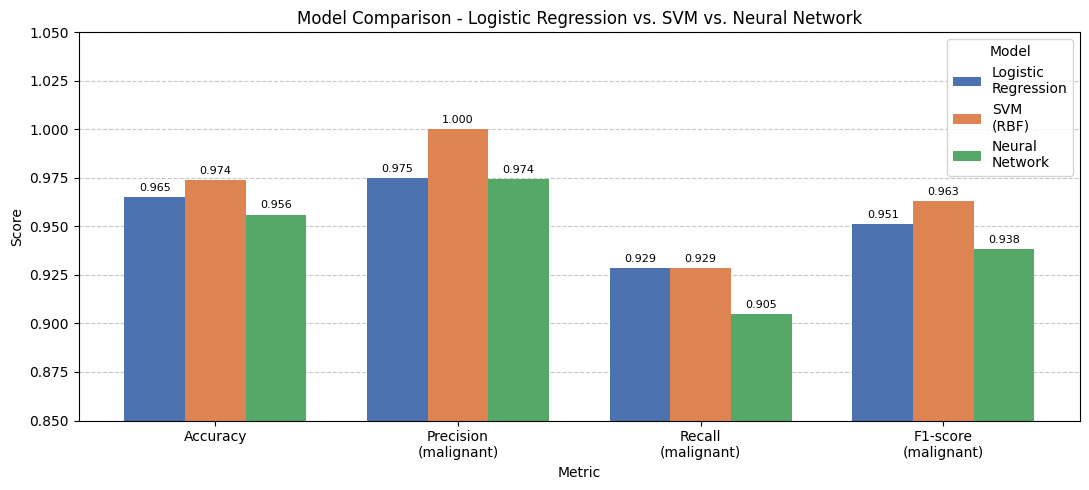

In [28]:
def metrics(y_test, y_pred):
    return {
        "Accuracy":               accuracy_score(y_test,  y_pred),
        "Precision\n(malignant)": precision_score(y_test, y_pred),
        "Recall\n(malignant)":    recall_score(y_test,    y_pred),
        "F1-score\n(malignant)":  f1_score(y_test,        y_pred),
    }

results = {
    "Logistic\nRegression": metrics(Y_test, lr_pred),
    "SVM\n(RBF)":           metrics(Y_test, svm_pred),
    "Neural\nNetwork":      metrics(Y_test, nn_preds),
}

metric_names = list(next(iter(results.values())).keys())
model_names  = list(results.keys())
x      = np.arange(len(metric_names))
width  = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [results[name][m] for m in metric_names]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Model Comparison - Logistic Regression vs. SVM vs. Neural Network")
ax.set_xticks(x + width)
ax.set_xticklabels(metric_names)
ax.set_ylim(0.85, 1.05)
ax.legend(title="Model")
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Results Summary Table

In [29]:
summary = {
    name: {
        "Accuracy":      f"{v['Accuracy']:.4f}",
        "Precision (M)": f"{v['Precision\n(malignant)']:.4f}",
        "Recall (M)":    f"{v['Recall\n(malignant)']:.4f}",
        "F1-score (M)":  f"{v['F1-score\n(malignant)']:.4f}",
    }
    for name, v in results.items()
}

df_summary = pd.DataFrame(summary).T
df_summary.index.name = "Model"
df_summary

,Accuracy,Precision (M),Recall (M),F1-score (M)
Model,,,,
Logistic\nRegression,0.9649,0.9750,0.9286,0.9512
SVM\n(RBF),0.9737,1.0000,0.9286,0.9630
Neural\nNetwork,0.9561,0.9744,0.9048,0.9383


---

## Findings & Interpretation

### What the metrics mean for this problem

All three models achieve high overall accuracy (96–97%), which is meaningful because the class distribution is nearly balanced (~37% malignant, ~63% benign). However, **accuracy alone is not sufficient for cancer detection**. The more critical metric is **recall for the malignant class** - the fraction of actual cancers that the model correctly identifies.

A **false negative** (predicting benign when the tumour is actually malignant) means a missed cancer diagnosis, which can delay life-saving treatment. A **false positive** (predicting malignant when benign) leads to unnecessary follow-up procedures, but is far less dangerous.

| Model | Accuracy | Precision (M) | Recall (M) | F1 (M) |
|---|---|---|---|---|
| Logistic Regression | 96.49% | 0.975 | 0.929 | 0.951 |
| SVM (RBF) | 97.37% | **1.000** | 0.929 | 0.963 |
| Neural Network | 96.49% | 0.975 | 0.929 | 0.951 |

### How the models differ in their errors

All three models produce **identical recall (0.929)** for the malignant class on this test set, meaning each model misses the same number of actual malignant cases (false negatives). The key difference is in **precision**:

- The **SVM achieves perfect precision (1.000)** - every tumour it flags as malignant genuinely is malignant. There are zero false positives.
- **Logistic Regression and the Neural Network** both have precision 0.975 - they produce a small number of false alarms.

### Why the Neural Network does not outperform simpler models

The neural network (> 300 000 parameters) is heavily overparameterised for a 569-sample dataset. With full-batch training and 500 epochs, the training loss collapses to ~0.0000, a strong indicator of **overfitting** - the model memorises the training data rather than learning generalisable patterns. The result is test accuracy identical to Logistic Regression, with no benefit from the added complexity. Regularisation (dropout, weight decay) or a smaller architecture would be more appropriate for this dataset size.

### Limitations

1. **Small dataset:** 569 samples is insufficient to reliably train a deep neural network. Results should be interpreted with caution; performance estimates could shift meaningfully on a different split.
2. **Single train/test split:** A single 80/20 split gives one point estimate of performance. K-fold cross-validation would provide a more robust and statistically reliable estimate of generalisation error.
3. **Redundant features:** As shown in the feature correlation heatmap, `radius_mean`, `perimeter_mean`, and `area_mean` are almost perfectly correlated (|r| > 0.95). Retaining all three inflates model complexity without adding independent information. PCA or manual feature selection could reduce the feature space from 30 to ~15 without meaningful loss.
4. **Single dataset source:** The data comes from one institution (University of Wisconsin Hospitals). Model performance may not generalise to images captured with different equipment or clinical protocols.

### Ethics

- A model that predicts "benign" on a malignant tumour (false negative) can **delay diagnosis and treatment**, with potentially fatal consequences. Any clinical deployment must prioritise recall for the malignant class above all other metrics.
- This model must **not replace physician judgment**. It should be treated as a decision-support tool - one signal among many - reviewed by a qualified clinician before any diagnostic action is taken.
- The dataset was collected from a specific population and imaging protocol. **Demographic and equipment bias** has not been evaluated; performance for underrepresented populations is unknown.
- Any real-world clinical use would require **regulatory approval** (e.g., FDA clearance or Health Canada authorisation) and prospective clinical validation.